Notebook này trình bay hai ví dụ về cách implement Một mạng Neural Multilayers dựa các công thức đã được giới thiệu trong bài giảng trên lớp cũng như trong file Lab hôm nay. Notebook gồm hai phần chính:
- 1. Cách Implement một mạng Neural với L-Layers cho bài toán Binary Classification
- 2. Cách Implement một mạng Neural với L-Layers cho bài toán MNIST sử dụng Softmax activation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [2]:
def add_intercept(x):
    """
      Dùng cho tất cả các bài trong file

    Args:
        x: 2D NumPy array.

    Returns:
        New matrix same as x with 1's in the 0th column.
    """
    new_x = np.zeros((x.shape[0], x.shape[1] + 1), dtype=x.dtype)
    new_x[:, 0] = 1
    new_x[:, 1:] = x

    return new_x


def load_dataset(csv_path, label_col='y', bias=False):
    """
    Dùng cho dataset ds1_train
    """


    # Validate label_col argument
    allowed_label_cols = ('y', 't')
    if label_col not in allowed_label_cols:
        raise ValueError('Invalid label_col: {} (expected {})'
                         .format(label_col, allowed_label_cols))

    # Load headers
    with open(csv_path, 'r') as csv_fh:
        headers = csv_fh.readline().strip().split(',')

    # Load features and labels
    x_cols = [i for i in range(len(headers)) if headers[i].startswith('x')]
    l_cols = [i for i in range(len(headers)) if headers[i] == label_col]
    inputs = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=x_cols)
    labels = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=l_cols)

    if inputs.ndim == 1:
        inputs = np.expand_dims(inputs, -1)

    if bias:
        inputs = add_intercept(inputs)

    return inputs, labels

ds1_training_set_path = 'ds1_train.csv'
ds1_valid_set_path = 'ds1_valid.csv'

# Multi Layer - (Đọc thêm)

Như vậy, ta đã tìm hiểu về mạng nơ-ron và cách để xây dựng một mạng neural đơn giản hai lớp. Dựa trên đó, ta có thể xây dựng một **Mạng Neural Đa lớp (Multi Layer Perceptron - MLP)**.

Sự lan truyền tiến (Forward Pass) của mạng được định nghĩa như sau:

* **Lớp ẩn ($k = 1, \dots, r-1$):**
    $$a^{[k]} = \text{ReLU}\left(W^{[k]}a^{[k-1]} + b^{[k]}\right)$$
* **Lớp đầu ra ($k=r$):**
    $$a^{[r]} = z^{[r]} = W^{[r]}a^{[r-1]} + b^{[r]}$$

Với hàm mất mát (loss function) là:
$$J = \frac{1}{2}(a^{[r]} - y)^2$$

Thuật toán lan truyền ngược (Backpropagation) giúp tính toán gradient của hàm mất mát $J$ theo các tham số.



---
Như vậy, thuật toán của chúng ta cho trường hợp đa lớp có thể tóm tắt lại như sau:

### 1. Lan truyền Tiến

-  Tính toán và lưu trữ các giá trị $a^{[k]}$, $z^{[k]}$ cho $k = 1, \dots, r-1$, và $J$.

### 2. Lan truyền Ngược

-  Tính $\delta^{[r]}$ tại lớp đầu ra $r$:
  $$\delta^{[r]} = \frac{\partial J}{\partial z^{[r]}} = (z^{[r]} - y)$$

-  Vòng lặp ngược từ $k = r-1$ về $1$:
    -  Tính $\delta^{[k]}$ (gradient của đầu vào đã kích hoạt):
        $$\delta^{[k]} = \frac{\partial J}{\partial z^{[k]}} = \left(W^{[k+1]\top} \delta^{[k+1]}\right) \odot \text{ReLU}'(z^{[k]})$$
    -  Tính các đạo hàm của $J$ theo tham số ở lớp $k+1$:
        $$\frac{\partial J}{\partial W^{[k+1]}} = \delta^{[k+1]}a^{[k]\top}$$
        $$\frac{\partial J}{\partial b^{[k+1]}} = \delta^{[k+1]}$$

In [3]:
def sigmoid(Z):
    A = 1 / (1 + np.exp(-Z))
    return A

def sigmoid_backward(dA, Z):
    s = 1 / (1 + np.exp(-Z))
    dZ = dA * s * (1 - s)
    return dZ

def relu(Z):
    A = np.maximum(0, Z)
    return A

def relu_backward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def tanh(Z):
    A = np.tanh(Z)
    return A

def tanh_backward(dA, Z):
    A = np.tanh(Z)
    dZ = dA * (1 - np.power(A, 2))
    return dZ

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    return A

## 1. Ví dụ 1:

In [4]:
class MultiLayerNN:

    def __init__(self, layer_dims):
        self.layer_dims = layer_dims
        self.L = len(layer_dims) - 1
        self.parameters = self._initialize_parameters_deep()
        self.caches = []

    ## 1. Khởi tạo Tham số (Không thay đổi)
    def _initialize_parameters_deep(self):
        parameters = {}

        for l in range(1, self.L + 1):
            parameters['W' + str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * 0.01
            parameters['b' + str(l)] = np.zeros((self.layer_dims[l], 1))
            assert(parameters['W' + str(l)].shape == (self.layer_dims[l], self.layer_dims[l-1]))
            assert(parameters['b' + str(l)].shape == (self.layer_dims[l], 1))
        return parameters

    ## 2. Forward

    def _linear_forward(self, A_prev, W, b):
        Z = np.dot(W, A_prev) + b
        linear_cache = (A_prev, W, b)
        return Z, linear_cache

    def _linear_activation_forward(self, A_prev, W, b, activation):
        Z, linear_cache = self._linear_forward(A_prev, W, b)

        if activation == "tanh":
            A = tanh(Z)
        elif activation == "sigmoid":
            A = sigmoid(Z)

        activation_cache = Z
        cache = (linear_cache, activation_cache)
        return A, cache

    def forward_propagation(self, X):
        caches = []
        A = X

        # [LINEAR -> TANH] * (L-1)
        for l in range(1, self.L):
            A_prev = A
            W = self.parameters['W' + str(l)]
            b = self.parameters['b' + str(l)]
            A, cache = self._linear_activation_forward(A_prev, W, b, "tanh")
            caches.append(cache)

        # LINEAR -> SIGMOID (Lớp đầu ra vẫn giữ nguyên)
        W = self.parameters['W' + str(self.L)]
        b = self.parameters['b' + str(self.L)]
        AL, cache = self._linear_activation_forward(A, W, b, "sigmoid")
        caches.append(cache)

        self.caches = caches
        return AL

    def compute_cost(self, AL, Y):
        m = Y.shape[1]
        AL = np.clip(AL, 1e-12, 1 - 1e-12)
        cost = (-1 / m) * np.sum(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))
        return float(np.squeeze(cost))

    ## 2. BACKWARD

    def _linear_backward(self, dZ, linear_cache):
        A_prev, W, b = linear_cache
        m = A_prev.shape[1]
        dW = (1 / m) * np.dot(dZ, A_prev.T)
        db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = np.dot(W.T, dZ)
        return dA_prev, dW, db

    def _linear_activation_backward(self, dA, cache, activation):
        linear_cache, activation_cache = cache
        Z = activation_cache

        if activation == "tanh":
            dZ = tanh_backward(dA, Z)
        elif activation == "sigmoid":
            dZ = sigmoid_backward(dA, Z)

        dA_prev, dW, db = self._linear_backward(dZ, linear_cache)
        return dA_prev, dW, db

    def backward_propagation(self, Y, AL):
        grads = {}
        dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))

        # Lớp L (SIGMOID -> LINEAR)
        current_cache = self.caches[self.L - 1]
        dA_prev_temp, dW_temp, db_temp = self._linear_activation_backward(dAL, current_cache, "sigmoid")
        grads["dA" + str(self.L - 1)] = dA_prev_temp
        grads["dW" + str(self.L)] = dW_temp
        grads["db" + str(self.L)] = db_temp

        # Lớp L-1 đến 1 (TANH -> LINEAR)
        for l in reversed(range(self.L - 1)):
            current_cache = self.caches[l]
            dA_prev_temp, dW_temp, db_temp = self._linear_activation_backward(
                grads["dA" + str(l + 1)], current_cache, activation = "tanh"
            )
            grads["dA" + str(l)] = dA_prev_temp
            grads["dW" + str(l + 1)] = dW_temp
            grads["db" + str(l + 1)] = db_temp

        return grads

    ## 5. Cập nhật Tham số
    def update_parameters(self, grads, learning_rate):
        for l in range(1, self.L + 1):
            self.parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
            self.parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]

In [5]:
def predict(model, X):
    AL = model.forward_propagation(X)
    predictions = (AL > 0.5).astype(int)
    return predictions

def train_network(model, X_train, Y_train, X_valid, Y_valid,
                  num_iterations=10000, learning_rate=0.0075, print_cost=True,
                  eval_freq=1000):

    for i in range(num_iterations):
        AL = model.forward_propagation(X_train)
        cost = model.compute_cost(AL, Y_train)

        grads = model.backward_propagation(Y_train, AL)

        model.update_parameters(grads, learning_rate)

        if print_cost and (i % eval_freq == 0 or i == num_iterations - 1):

            Y_valid_pred = predict(model, X_valid)
            valid_acc = np.mean(Y_valid_pred == Y_valid)

            Y_train_pred = predict(model, X_train)
            train_acc = np.mean(Y_train_pred == Y_train)

            print(f"Iteration {i:5d}/{num_iterations} | Cost: {cost:.6f} | Train Acc: {train_acc:.4f} | Valid Acc: {valid_acc:.4f}")


In [6]:
# Ta không thêm bias vào vì bản thân trong mạng đã có bias
X_train_raw, Y_train_raw = load_dataset(ds1_training_set_path, bias=False)
X_valid_raw, Y_valid_raw = load_dataset(ds1_valid_set_path, bias=False)

# Chuyển X từ (n_samples, n_features) → (n_features, n_samples)
# vì trong các công thức vectorized của neural network,
# mỗi cột là 1 mẫu (x^i). Nếu không .T thì mỗi hàng lại trở thành 1 mẫu,
# dẫn đến sai toàn bộ tích ma trận W @ X.

X_train = X_train_raw.T
X_valid = X_valid_raw.T

# Chuyển Y từ vector (n_samples,) → ma trận (1, n_samples)
# vì ta muốn Y có shape tương ứng với output layer shape (1, m_samples),
# phục vụ cho phép broadcast trong loss và backprop.

Y_train = Y_train_raw.reshape(1, -1)
Y_valid = Y_valid_raw.reshape(1, -1)

In [7]:
INPUT_DIM = X_train.shape[0]
OUTPUT_DIM = Y_train.shape[0]
print(INPUT_DIM, OUTPUT_DIM)

layer_dims = [INPUT_DIM, 4, OUTPUT_DIM]
print(f"Cấu trúc lớp được sử dụng: {layer_dims}")

nn_model = MultiLayerNN(layer_dims)

NUM_ITER = 10000
LEARNING_RATE = 0.1

train_network(
    nn_model,
    X_train, Y_train,
    X_valid, Y_valid,
    num_iterations=NUM_ITER,
    learning_rate=LEARNING_RATE,
)

2 1
Cấu trúc lớp được sử dụng: [2, 4, 1]
Iteration     0/10000 | Cost: 0.692218 | Train Acc: 0.5000 | Valid Acc: 0.5000
Iteration  1000/10000 | Cost: 0.690921 | Train Acc: 0.5188 | Valid Acc: 0.5100
Iteration  2000/10000 | Cost: 0.490787 | Train Acc: 0.7512 | Valid Acc: 0.8100
Iteration  3000/10000 | Cost: 0.468580 | Train Acc: 0.7800 | Valid Acc: 0.8400
Iteration  4000/10000 | Cost: 0.466477 | Train Acc: 0.7788 | Valid Acc: 0.7700
Iteration  5000/10000 | Cost: 0.404087 | Train Acc: 0.8375 | Valid Acc: 0.8100
Iteration  6000/10000 | Cost: 0.407247 | Train Acc: 0.8200 | Valid Acc: 0.8200
Iteration  7000/10000 | Cost: 0.415597 | Train Acc: 0.7937 | Valid Acc: 0.7700
Iteration  8000/10000 | Cost: 0.449061 | Train Acc: 0.8187 | Valid Acc: 0.8200
Iteration  9000/10000 | Cost: 0.410031 | Train Acc: 0.8113 | Valid Acc: 0.8000
Iteration  9999/10000 | Cost: 0.383000 | Train Acc: 0.8350 | Valid Acc: 0.8500


## 2. Ví dụ 2: Mạng Nơ-ron Sâu (L-Layers) cho Phân loại Đa Lớp (MNIST)

## Ý tưởng và Mục tiêu

Mục tiêu là xây dựng một mạng nơ-ron có $L$ tầng để phân loại hình ảnh chữ số viết tay **MNIST** (10 lớp: 0 đến 9).

### 1. Phân loại Đa Lớp (Multi-class Classification)
Bài toán MNIST yêu cầu gán một trong 10 nhãn cho mỗi đầu vào. Để xử lý đầu ra đa lớp, ta sử dụng:
* **Hàm kích hoạt Softmax** ở tầng đầu ra ($L$).
* **Hàm mất mát Categorical Cross-Entropy (CCE)**.

### 2. Kiến trúc (Architecture)
* **Đầu vào $X$**: Vector hóa ảnh $28 \times 28$ thành $784$ features.
* **Tầng Ẩn (Hidden Layers)**: Chuỗi các tầng **LINEAR $\rightarrow$ ReLU**.
* **Tầng Đầu ra (Output Layer)**: Một tầng **LINEAR $\rightarrow$ Softmax**, với số lượng nơ-ron bằng số lớp (10).

### 3. Chi tiết Triển khai (Implementation Details)

#### 3.1. Khởi tạo Tham số (`_initialize_parameters_deep`)
Sử dụng **He Initialization** để khởi tạo các ma trận **weight** $W^{[l]}$ và **bias** $b^{[l]}$. Phương pháp này đặc biệt hiệu quả khi sử dụng ReLU, giúp duy trì variance của kích hoạt qua các tầng.

$$\text{Khởi tạo } W^{[l]}: W^{[l]} \sim \mathcal{N}\left(0, \sqrt{\frac{2.0}{\text{layer_dims}[l-1]}}\right)$$

#### 3.2. Định dạng Dữ liệu Đầu ra $Y$
Nhãn $Y$ (kích thước $m$ mẫu) phải được chuyển thành định dạng **One-Hot Encoding** (kích thước $10 \times m$) để tương thích với Softmax và CCE.

| Nhãn số | One-Hot Vector |
| :--- | :--- |
| 3 | $[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]^T$ |
| 7 | $[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]^T$ |

---
### 4. Forward Implement

#### 4.1. Tầng Ẩn (Linear $\rightarrow$ ReLU)
Áp dụng cho $l = 1$ đến $L-1$:
$$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = \text{ReLU}(Z^{[l]}) = \text{max}(0, Z^{[l]})$$

#### 4.2. Tầng Đầu ra (Linear $\rightarrow$ Softmax)
Áp dụng cho tầng $L$:
$$AL = \text{Softmax}(Z^{[L]})$$
$$\text{Softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}$$

#### 4.3. Tính Chi phí (`compute_cost`)
Sử dụng **Categorical Cross-Entropy Loss** ($C=10$):
$$J = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{C} Y_{k}^{(i)} \log(AL_{k}^{(i)})$$

---
### 5. Backward Implement
#### 5.1. Xử lý Tầng Đầu ra ($L$) (Softmax + CCE)
Đạo hàm gộp của CCE theo $Z^{[L]}$:
$$dZ^{[L]} = AL - Y$$
Sau đó, áp dụng **Linear Backward** để tính $dW^{[L]}$, $db^{[L]}$, và $dA^{[L-1]}$.

 $$dW^{[L]} = \frac{1}{m} dZ^{[L]} (A^{[L-1]})^T$$
 $$db^{[L]} = \frac{1}{m} \sum_{\text{columns}} dZ^{[L]}$$
 $$dA^{[L-1]} = (W^{[L]})^T dZ^{[L]}$$

#### 5.2. Lan truyền Ngược qua Tầng Ẩn ($l = L-1$ đến $1$)
Tính $dZ^{[l]}$ thông qua đạo hàm của ReLU (`relu_backward`):
$$dZ^{[l]} = dA^{[l]} \odot \mathbf{1}\{Z^{[l]} > 0\}$$
Sau đó, áp dụng **Linear Backward** để tính $dW^{[l]}$, $db^{[l]}$, và $dA^{[l-1]}$.

#### 5.3. Cập nhật Tham số (`update_parameters`)
Sử dụng **Gradient Descent** với tốc độ học $\alpha$:
$$\theta^{[l]} = \theta^{[l]} - \alpha \cdot d\theta^{[l]}$$

In [8]:
class SoftmaxNN:

    def __init__(self, layer_dims):
        self.layer_dims = layer_dims
        self.L = len(layer_dims) - 1
        self.parameters = self._initialize_parameters_deep()
        self.caches = []

    ## 1. Khởi tạo Tham số
    def _initialize_parameters_deep(self):
        np.random.seed(3)
        parameters = {}
        for l in range(1, self.L + 1):
            he_init_scale = np.sqrt(2.0 / self.layer_dims[l-1])
            parameters['W' + str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * he_init_scale
            parameters['b' + str(l)] = np.zeros((self.layer_dims[l], 1))
        return parameters

    ## 2. Forward

    def _linear_forward(self, A_prev, W, b):
        Z = np.dot(W, A_prev) + b
        linear_cache = (A_prev, W, b)
        return Z, linear_cache

    def _linear_activation_forward(self, A_prev, W, b, activation):
        Z, linear_cache = self._linear_forward(A_prev, W, b)

        if activation == "relu":
            A = relu(Z)
        elif activation == "softmax":
            A = softmax(Z)

        activation_cache = Z
        cache = (linear_cache, activation_cache)
        return A, cache

    def forward_propagation(self, X):
        caches = []
        A = X

        # [LINEAR -> ReLU] * (L-1)
        for l in range(1, self.L):
            A_prev = A
            W = self.parameters['W' + str(l)]
            b = self.parameters['b' + str(l)]
            A, cache = self._linear_activation_forward(A_prev, W, b, "relu")
            caches.append(cache)

        # LINEAR -> SOFTMAX (Lớp đầu ra)
        W = self.parameters['W' + str(self.L)]
        b = self.parameters['b' + str(self.L)]
        AL, cache = self._linear_activation_forward(A, W, b, "softmax")
        caches.append(cache)

        self.caches = caches
        return AL

    def compute_cost(self, AL, Y):
        m = Y.shape[1]
        AL = np.clip(AL, 1e-12, 1)

        # Công thức Categorical Cross-Entropy: J = -(1/m) * sum(Y * log(AL))
        # Do Y là one-hot, phép nhân này chỉ giữ lại log(AL) cho lớp đúng.
        cost = (-1 / m) * np.sum(Y * np.log(AL))

        return float(np.squeeze(cost))

    ## Backward

    def _linear_backward(self, dZ, linear_cache):
        A_prev, W, b = linear_cache
        m = A_prev.shape[1]
        dW = (1 / m) * np.dot(dZ, A_prev.T)
        db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = np.dot(W.T, dZ)
        return dA_prev, dW, db

    def _linear_activation_backward(self, dA, cache, activation):
        linear_cache, activation_cache = cache
        Z = activation_cache

        if activation == "relu":
            dZ = relu_backward(dA, Z)

        # Softmax Backward không cần ở đây vì nó được xử lý đặc biệt ở bước sau
        # Nếu là lớp giữa, ta phải có đạo hàm của Softmax, nhưng Softmax thường là lớp cuối.

        dA_prev, dW, db = self._linear_backward(dZ, linear_cache)
        return dA_prev, dW, db

    def backward_propagation(self, Y, AL):
        grads = {}

        # Đạo hàm cho lớp cuối cùng (Softmax + Cross-Entropy)
        # Đạo hàm của J theo ZL khi dùng Softmax và CCE là: dAL/dZL = AL - Y
        dZL = AL - Y

        # Lớp L (SOFTMAX -> LINEAR)
        current_cache = self.caches[self.L - 1]
        linear_cache, activation_cache = current_cache # Tách linear cache (A_prev, W, b)

        # Tính dW, db, dA_prev cho lớp L từ dZL (dZ)
        dA_prev_temp, dW_temp, db_temp = self._linear_backward(dZL, linear_cache)

        grads["dA" + str(self.L - 1)] = dA_prev_temp
        grads["dW" + str(self.L)] = dW_temp
        grads["db" + str(self.L)] = db_temp

        # Lớp L-1 đến 1 (TANH -> LINEAR)
        for l in reversed(range(self.L - 1)):
            current_cache = self.caches[l]
            dA_prev_temp, dW_temp, db_temp = self._linear_activation_backward(
                grads["dA" + str(l + 1)], current_cache, activation = "relu"
            )
            grads["dA" + str(l)] = dA_prev_temp
            grads["dW" + str(l + 1)] = dW_temp
            grads["db" + str(l + 1)] = db_temp

        return grads

    def update_parameters(self, grads, learning_rate):
        for l in range(1, self.L + 1):
            self.parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
            self.parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]

In [9]:
from sklearn.datasets import fetch_openml

def preprocess_mnist():
    mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
    X, Y = mnist.data, mnist.target.astype(int)
    X = X.T / 255.0

    m = Y.shape[0]

    num_classes = 10
    Y_one_hot = np.zeros((num_classes, m))
    Y_one_hot[Y, np.arange(m)] = 1  # shape (10, m)

    # Split: train 50k, val 10k
    X_train = X[:, :50000]
    Y_train = Y[:50000]
    Y_train_oh = Y_one_hot[:, :50000]

    X_val = X[:, 50000:60000]
    Y_val = Y[50000:60000]
    Y_val_oh = Y_one_hot[:, 50000:60000]

    # Test set (10k)
    X_test = X[:, 60000:]
    Y_test = Y[60000:].reshape(1, -1)
    Y_test_oh = Y_one_hot[:, 60000:]

    return X_train, Y_train, Y_train_oh, X_val, Y_val, Y_val_oh, X_test, Y_test, Y_test_oh

In [10]:
X_train, Y_train, Y_train_oh, \
X_val, Y_val, Y_val_oh, \
X_test, Y_test, Y_test_oh = preprocess_mnist()

print("Train:", X_train.shape, Y_train_oh.shape)
print("Val  :", X_val.shape, Y_val_oh.shape)
print("Test :", X_test.shape, Y_test.shape)

Train: (784, 50000) (10, 50000)
Val  : (784, 10000) (10, 10000)
Test : (784, 10000) (1, 10000)


In [11]:
def predict(model, X):
    """
    Thay đổi cho SoftmaxNN
    """
    AL = model.forward_propagation(X)
    predictions = np.argmax(AL, axis=0)

    return predictions.reshape(1, -1)

def train_network(model, X_train, Y_onehot, X_valid, Y_valid,
                  num_iterations=10000, learning_rate=0.0075, print_cost=True,
                  eval_freq=1000, Y_train=None):

    # Tạo progress bar
    pbar = tqdm(range(num_iterations), desc="Training Network", unit="iter")

    for i in pbar:

        # 1. Forward Propagation
        AL = model.forward_propagation(X_train)

        # 2. Compute Cost
        cost = model.compute_cost(AL, Y_onehot)

        # 3. Backward Propagation
        grads = model.backward_propagation(Y_onehot, AL)

        # 4. Update Parameters
        model.update_parameters(grads, learning_rate)

        # 5. Eva;l
        if print_cost and (i % eval_freq == 0 or i == num_iterations - 1):


            Y_valid_pred = predict(model, X_valid)
            valid_acc = np.mean(Y_valid_pred == Y_valid)

            Y_train_pred = predict(model, X_train)
            train_acc = np.mean(Y_train_pred == Y_train)

            pbar.set_postfix({
                "cost": f"{cost:.6f}",
                "train_acc": f"{train_acc:.4f}",
                "valid_acc": f"{valid_acc:.4f}"
            })

    if print_cost:
        print(f"\nFinal | Cost: {cost:.6f} | Train Acc: {train_acc:.4f} | Valid Acc: {valid_acc:.4f}")

In [12]:
layer_dims_mnist = [784, 128, 64, 10]
model_mnist = SoftmaxNN(layer_dims_mnist)

train_network(
    model_mnist,
    X_train, Y_train_oh,
    X_val, Y_val,
    num_iterations=250,
    learning_rate=0.01,
    eval_freq = 5,
    Y_train = Y_train
)

Training Network: 100%|██████████| 250/250 [04:50<00:00,  1.16s/iter, cost=0.871666, train_acc=0.8031, valid_acc=0.8227]


Final | Cost: 0.871666 | Train Acc: 0.8031 | Valid Acc: 0.8227


In [13]:
pred = predict(model_mnist, X_test)
test_acc = np.mean(pred == Y_test)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.8093


In [14]:
def visualize_predictions(model, X, Y_valid, num_samples=10, image_shape=(28, 28)):

    Y_true_flat = Y_valid.flatten()

    AL = model.forward_propagation(X)
    Y_pred_flat = predict(model, X).flatten()

    correct_indices = np.where(Y_pred_flat == Y_true_flat)[0]
    incorrect_indices = np.where(Y_pred_flat != Y_true_flat)[0]

    np.random.shuffle(correct_indices)
    np.random.shuffle(incorrect_indices)

    correct_to_show = correct_indices[:num_samples]
    incorrect_to_show = incorrect_indices[:num_samples]


    plt.figure(figsize=(20, 4))
    plt.suptitle(f'Correct Classification', fontsize=16)

    for i, idx in enumerate(correct_to_show):
        if i >= num_samples: break

        ax = plt.subplot(1, num_samples, i + 1)

        image = X[:, idx].reshape(image_shape)

        plt.imshow(image, cmap='gray')
        plt.title(f"Groundtruth: {Y_true_flat[idx]}\n Predict: {Y_pred_flat[idx]}", color='green')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


    plt.figure(figsize=(20, 4))
    plt.suptitle(f'Misclassification', fontsize=16)

    for i, idx in enumerate(incorrect_to_show):
        if i >= num_samples: break

        ax = plt.subplot(1, num_samples, i + 1)

        image = X[:, idx].reshape(image_shape)

        plt.imshow(image, cmap='gray')
        plt.title(f"Groundtruth: {Y_true_flat[idx]}\nPredict: {Y_pred_flat[idx]}", color='red')
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

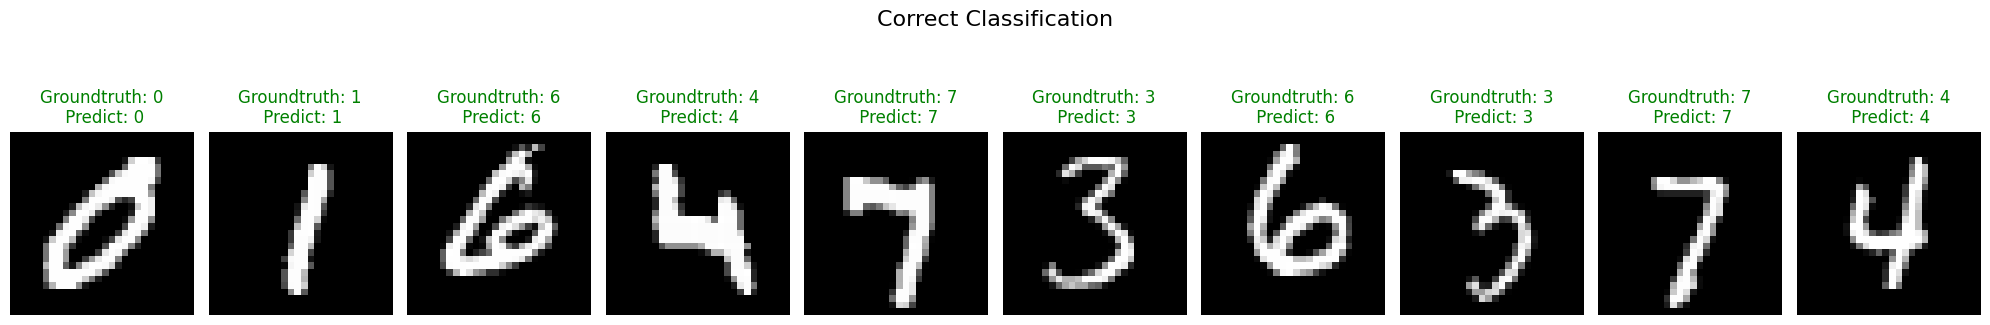

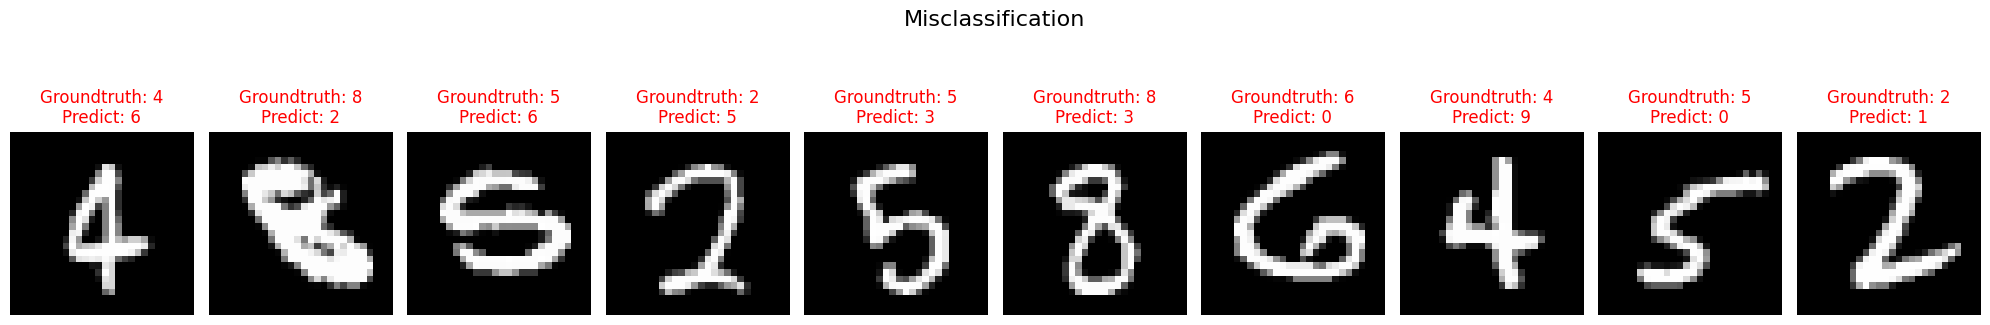

In [15]:
visualize_predictions(
    model=model_mnist,
    X=X_test,
    Y_valid=Y_test,
    num_samples=10,
    image_shape=(28, 28)
)